## Alzheimer Detection using Google Colaboratory

### Step 0: Import Libraries and Clone Repository

In [2]:
%cd /content/
!git clone https://github.com/Verbosi7y/ai-alzheimer-detection.git

/content
fatal: destination path 'ai-alzheimer-detection' already exists and is not an empty directory.


In [3]:
%pip install --upgrade pip
%pip install torch
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-image
%pip install scikit-learn
%pip install imbalanced-learn
%pip install albumentations
%pip install opencv-python
%pip install pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.6 MB/s eta 0:00:0000:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 84.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 56.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 95.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 123.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 126.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 120.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 28.9 MB/s eta 0:00:00:00:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: n

In [ ]:
# Uncomment if you are running Google Colab on a CUDA GPU (NVIDIA)
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [4]:
from torch.utils.data import DataLoader

import os
import sys

Setting Paths

In [5]:
parent_path = r"/content/ai-alzheimer-detection"

kaggle_dir = r"assets/Kaggle"
kaggle_path = os.path.join(parent_path, kaggle_dir)

kaggle_dataset_dir = r"alzheimer_mri_preprocessed_dataset"
kaggle_raw_dir = r"alzheimer_mri_preprocessed_dataset/raw"

kaggle_dataset_path = os.path.join(kaggle_path, kaggle_dataset_dir)
kaggle_raw_path = os.path.join(kaggle_path, kaggle_raw_dir)

model_dir = r"models"
model_path = os.path.join(parent_path, model_dir)

if not os.path.exists(model_path):
    os.makedirs(model_path)

model_dir = r"models/best_ad_model.pth"
model_path = os.path.join(parent_path, model_dir)

In [6]:
# add parent to path
sys.path.append(parent_path)

### Step 1: Load the Dataset

In [7]:
from alzheimersdetection import Dataset

X, y = Dataset.step1_load_data(path=kaggle_raw_path) # np.array, np.array

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Images:  (6400, 128, 128)
Labels:  (6400,)


### Step 2: Split the dataset

Split the data into 80% training and 20% testing data. Ensure same class distribution using stratify=y (class/label).

Further split the training data into 75% training and 25% validation respectively.

Ratio: 60% Training : 20% Validation : 20% Testing

In [8]:
test_size = 0.20
validation_size = 0.25

split_dataset = Dataset.step2_split_data(X, y, test_size=test_size, validation_size=validation_size)

Before Validation - Training Data Shape: (5120, 128, 128)
Before Validation - Training Label Shape: (5120,)
Training Size:  (3840, 128, 128)
Test Size:  (1280, 128, 128)
Validation Size:  (1280, 128, 128)

Classes encoded for reference:  {'Non_Demented': 0, 'Very_Mild_Demented': 1, 'Mild_Demented': 2, 'Moderate_Demented': 3} 

Training Split:  (array([0, 1, 2, 3]), array([1920, 1344,  538,   38]))
Validation Split:  (array([0, 1, 2, 3]), array([640, 448, 179,  13]))
Testing Split:  (array([0, 1, 2, 3]), array([640, 448, 179,  13]))


Visualization for the Distribution of the Training Dataset

Results should be heavily imbalanced 

{'Non_Demented': 0, 'Very_Mild_Demented': 1, 'Mild_Demented': 2, 'Moderate_Demented': 3}
(array([0, 1, 2, 3]), array([1920, 1344,  538,   38]))


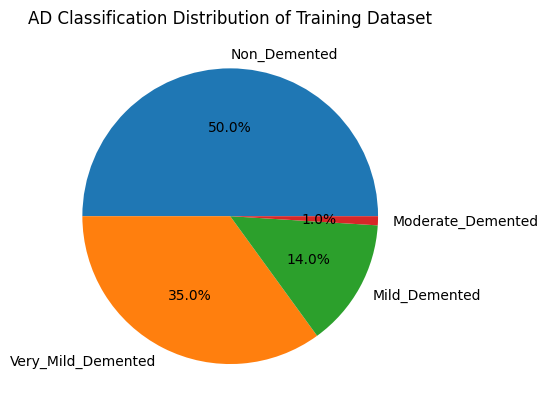

In [9]:
import stats.statistics as Statistics

title_before_aug = "AD Classification Distribution of Training Dataset"

sample_dist = Dataset.distribution(split_dataset["train"]["y"])

Statistics.pieChartClassificationPlot(sample_dist, title_before_aug)

### Step 3: Balance and Oversample the Dataset

#### 3a. Balance

To further balance the dataset, we need to employ more techniques. One of which is data augmentation.
Method to balance the data augmentation process is to define class-specific augmentation rates.

In [10]:
'''
    Rates:
    - Non_Demented: 1
    - Very_Mild_Demented: 1
    - Mild_Demented: 2
    - Moderate_Demented: 5
'''
rates = [1, 1, 2, 5]

split_dataset["train"] = Dataset.step3a_augmentation(split_dataset["train"], rates=rates)

Dataset.display_split(split_dataset=split_dataset)

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/content/ai-alzheimer-detection/alzheimersdetection/Dataset.py:83: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  aug.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=0, border_mode=cv2.BORDER_CONSTANT, value=0, p=1),


Training Size:  (8370, 128, 128)
Test Size:  (1280, 128, 128)
Validation Size:  (1280, 128, 128)

Classes encoded for reference:  {'Non_Demented': 0, 'Very_Mild_Demented': 1, 'Mild_Demented': 2, 'Moderate_Demented': 3} 

Training Split:  (array([0, 1, 2, 3]), array([3840, 2688, 1614,  228]))
Validation Split:  (array([0, 1, 2, 3]), array([640, 448, 179,  13]))
Testing Split:  (array([0, 1, 2, 3]), array([640, 448, 179,  13]))


Visualizing out results of the class distribution after data augmentation

{'Non_Demented': 0, 'Very_Mild_Demented': 1, 'Mild_Demented': 2, 'Moderate_Demented': 3}
(array([0, 1, 2, 3]), array([3840, 2688, 1614,  228]))


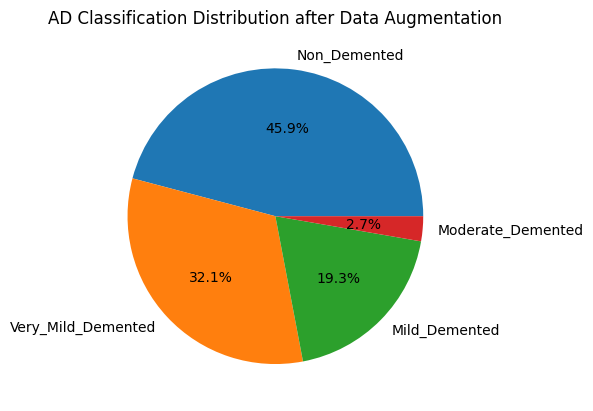

In [12]:
title_after_aug = "AD Classification Distribution after Data Augmentation"

aug_dist = Dataset.distribution(split_dataset["train"]["y"])

Statistics.pieChartClassificationPlot(aug_dist, title_after_aug)

#### 3b. ADASYN Oversampling

The dataset is still imbalanced and to fix this, we need to increase the minority class's representation (oversampling). This allows us to have a more balanced dataset.

We will be using Adaptive Synthetic Sampling (ADASYN) to oversample the minority classes.

In [ ]:
# Visualize class imbalance before ADASYN
title_before_ADASYN = "Class Distribution before ADASYN"

Dataset.display_split(split_dataset=split_dataset);

Statistics.ad_plot_bar(sample=split_dataset["train"], title=title_before_ADASYN)

Applying Adapative Synthetic Sampling (ADASYN)

Optimal Results: ~25% distribution across all AD classifications.

(15056, 128, 128)


/content/ai-alzheimer-detection/alzheimersdetection/Dataset.py:256: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(images[idx])


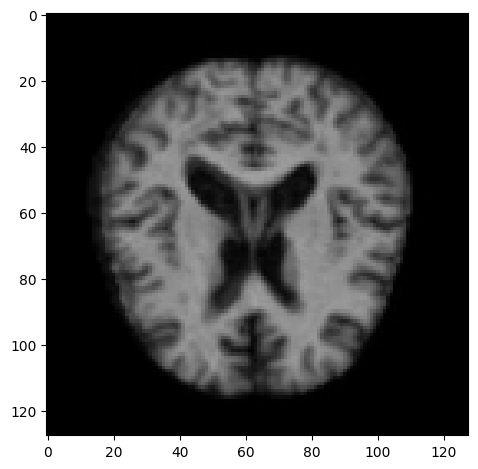

In [13]:
k = 5 # This is the k-neighbors which will be used for ADASYN

split_dataset["train"] = Dataset.step3b_ADASYN(sample=split_dataset["train"], k=k)

Visualizing our results after applying ADASYN as a Bar Plot

In [ ]:
# Visualize class imbalance after ADASYN
title_after_ADASYN = "Class Distribution after ADASYN"

Dataset.display_split(split_dataset=split_dataset);

Statistics.ad_plot_bar(sample=split_dataset["train"], title=title_after_ADASYN)

### Step 4: Save as dataset .npz and images

In [14]:
Dataset.step4_save_npz(split_dataset, path=kaggle_dataset_path)

[Training Dataset]: Saving...
[Training Dataset]: Done
[Testing Dataset]: Saving...
[Testing Dataset]: Done
[Validation Dataset]: Saving...
[Validation Dataset]: Done


### Step 5: Define Hyperparameters

In [15]:
param = {
        "epoches"       : 25, # implement early stopping
        "learning_rate" : 0.001,
        "batch_size"    : 8,
        "early_stop"    : 5
        }

### Step 6: Load Dataset as Dataloader

In [16]:
from alzheimersdetection.AlzheimerDataset import AlzheimerDataset

train_dataset = AlzheimerDataset(samples=split_dataset["train"])
val_dataset = AlzheimerDataset(samples=split_dataset["test"])
test_dataset = AlzheimerDataset(samples=split_dataset["validation"])

loaders =  {
           "train"  : DataLoader(train_dataset, batch_size=param["batch_size"], shuffle=True),
           "test"   : DataLoader(val_dataset, batch_size=param["batch_size"], shuffle=False),
           "val"    : DataLoader(test_dataset, batch_size=param["batch_size"], shuffle=False)
           }

### Step 7: Device Setup

Device Setup:

If you have an Nvidia GPU, you need to install CUDA

Otherwise, CPU will be used

In [17]:
from alzheimersdetection import AlzheimerModel

device = AlzheimerModel.set_device()

Hardware to be used: cuda:0
CUDA version: 12.4
Tesla P100-PCIE-16GB


### Step 8: Creating CNN Model

Create our model using PyTorch's Convolutional Neural Network

In [18]:
from alzheimersdetection.AlzheimerModel import AlzheimerCNN

model = AlzheimerCNN().to(device)

### Step 9: Train the Model

Criterion: Cross Entropy Loss

Optimizer: Adam

In [19]:
AlzheimerModel.step9_train_model(model, param, loaders, device, model_path)

epoch 1/25, training loss: 0.8006, validation loss: 65.0784, val acc: 0.5992
epoch 2/25, training loss: 0.4799, validation loss: 40.4321, val acc: 0.7688
epoch 3/25, training loss: 0.3151, validation loss: 35.7426, val acc: 0.8352
epoch 4/25, training loss: 0.1978, validation loss: 29.3169, val acc: 0.8641
epoch 5/25, training loss: 0.1271, validation loss: 28.6511, val acc: 0.8742
epoch 6/25, training loss: 0.0914, validation loss: 32.5599, val acc: 0.8703
epoch 7/25, training loss: 0.0729, validation loss: 17.6365, val acc: 0.9219
epoch 8/25, training loss: 0.0572, validation loss: 20.9236, val acc: 0.9047
epoch 9/25, training loss: 0.0414, validation loss: 24.7985, val acc: 0.9156
epoch 10/25, training loss: 0.0429, validation loss: 25.6666, val acc: 0.9078
epoch 11/25, training loss: 0.0294, validation loss: 21.3261, val acc: 0.9297
epoch 12/25, training loss: 0.0349, validation loss: 26.6172, val acc: 0.9117
Early Stop!
Stopped at Epoch: 11


### Step 10: Verify using Test Data

Non_Demented(0) - Accuracy: 0.94609375, Precision: 0.9192364170337739, Recall: 0.978125
Very_Mild_Demented(1) - Accuracy: 0.9421875, Precision: 0.9452380952380952, Recall: 0.8861607142857143
Mild_Demented(2) - Accuracy: 0.9828125, Precision: 0.9644970414201184, Recall: 0.9106145251396648
Moderate_Demented(3) - Accuracy: 0.99765625, Precision: 1.0, Recall: 0.7692307692307693


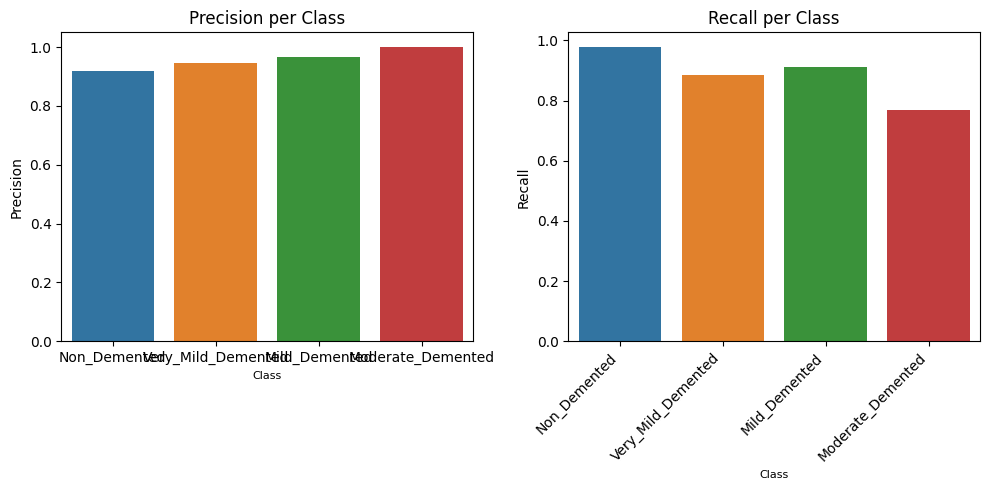

In [20]:
from alzheimersdetection import AlzheimerMetrics

AlzheimerMetrics.run_metrics(model, loaders["test"], device)